# Citi Bike — Follow-on Experiments Notebook (GPU Aware)

This notebook packages the next experiments into a single workflow that is easy to run after the capacity-merge fix:

- richer temporal features
- station-profile features
- spatial spillover features
- weather interactions
- capacity-engineered pressure features
- GPU-aware XGBoost experiments
- optional segmented-model and alert-task extensions

The default path is:
1. load `feature_df`
2. repair capacity if needed
3. engineer new feature blocks
4. run an expanded ablation table
5. compare Random Forest vs XGBoost
6. optionally try segmented models or classification


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# If xgboost is missing in a fresh Colab runtime, run this cell once.
try:
    import xgboost  # noqa: F401
except Exception:
    %pip install -q xgboost

In [3]:
from pathlib import Path
import io
import json
import math
import os
import re
import shutil
import subprocess
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
TARGET_COL = "departures_next_hour"
TOP_N_STATIONS = 100
TRAIN_FRAC = 0.70
VALID_FRAC = 0.15

FEATURE_CACHE_CANDIDATES = [
    Path("/content/drive/MyDrive/feature_df_model_ready_2025_v6.parquet"),
    Path("/content/outputs/feature_df_model_ready_2025_v6.parquet"),
    Path("/content/feature_df_model_ready_2025_v5.parquet"),
    Path("/mnt/data/feature_df_model_ready_2025_v6.parquet"),
    Path("/mnt/data/outputs/feature_df_model_ready_2025_v6.parquet"),
    Path("/mnt/data/feature_df_model_ready_2025_v5.parquet"),
]
STATION_LOOKUP_CANDIDATES = [
    Path("/content/station_lookup.csv"),
    Path("/mnt/data/station_lookup.csv"),
]
GBFS_STATION_INFO_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_information.json"


def locate_existing_path(candidates):
    for path in candidates:
        path = Path(path)
        if path.exists():
            return path
    return None


def detect_runtime_gpu():
    summary = {
        "nvidia_smi": False,
        "gpu_name": None,
        "xgboost_version": getattr(xgb, "__version__", "unknown"),
        "cuda_ready_for_xgb": False,
    }
    if shutil.which("nvidia-smi"):
        try:
            out = subprocess.check_output(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"], text=True)
            names = [line.strip() for line in out.splitlines() if line.strip()]
            if names:
                summary["nvidia_smi"] = True
                summary["gpu_name"] = names[0]
                summary["cuda_ready_for_xgb"] = True
        except Exception:
            pass
    return summary


GPU_INFO = detect_runtime_gpu()
print("XGBoost version:", GPU_INFO["xgboost_version"])
print("GPU detected by runtime:", GPU_INFO["nvidia_smi"])
print("GPU name:", GPU_INFO["gpu_name"])
print("XGBoost CUDA path enabled:", GPU_INFO["cuda_ready_for_xgb"])


XGBoost version: 3.2.0
GPU detected by runtime: True
GPU name: NVIDIA A100-SXM4-80GB
XGBoost CUDA path enabled: True


## 1) Load the feature table

This notebook expects the model-ready station-hour table. It will also try to repair capacity if the fixed merge has not already been propagated into `feature_df`.


In [4]:
feature_df_path = locate_existing_path(FEATURE_CACHE_CANDIDATES)
station_lookup_path = locate_existing_path(STATION_LOOKUP_CANDIDATES)

if feature_df_path is None:
    raise FileNotFoundError(
        "Could not find feature_df parquet. Update FEATURE_CACHE_CANDIDATES or copy the file into /content."
    )

print("Loading feature_df from:", feature_df_path)
feature_df = pd.read_parquet(feature_df_path)
print("feature_df shape:", feature_df.shape)
print("station_lookup path:", station_lookup_path)

for col in ["station_key", "station_cluster"]:
    if col in feature_df.columns:
        feature_df[col] = feature_df[col].astype("string")

if "hour" in feature_df.columns:
    feature_df["hour"] = pd.to_datetime(feature_df["hour"], errors="coerce")

feature_df.head(3)


Loading feature_df from: /content/drive/MyDrive/feature_df_model_ready_2025_v6.parquet
feature_df shape: (11966828, 66)
station_lookup path: /content/station_lookup.csv


,station_key,hour,departures,arrivals,net_flow,total_activity,station_name,lat,lng,capacity,is_active_station,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_commute_peak,is_overnight,hour_sin,hour_cos,dow_sin,dow_cos,is_holiday,is_precipitating,heavy_precip_flag,is_raining,is_snowing,departures_lag_1,departures_lag_2,departures_lag_24,departures_roll_3,departures_roll_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,arrivals_roll_3,arrivals_roll_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,net_flow_roll_3,net_flow_roll_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,total_activity_roll_3,total_activity_roll_24,departures_next_hour,arrivals_next_hour,net_flow_next_hour,utilization_ratio,utilization_ratio_lag_1
0,1234.56,2025-06-18 22:00:00,0,1,1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0,22,2,6,0,0,0,0,-0.500000,0.866025,0.974928,-0.222521,0,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN
1,1234.56,2025-06-18 23:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0,23,2,6,0,0,0,0,-0.258819,0.965926,0.974928,-0.222521,0,1,0,1,0,0.0,NaN,NaN,0.0,0.0,1.0,NaN,NaN,1.0,1.0,1.0,NaN,NaN,1.0,1.0,1.0,NaN,NaN,1.0,1.0,1.0,0.0,-1.0,NaN,NaN
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0,23,3,6,0,0,0,0,-0.258819,0.965926,0.433884,-0.900969,1,0,0,0,0,1.0,0.0,NaN,0.5,0.5,1.0,1.0,NaN,1.0,1.0,0.0,1.0,NaN,0.5,0.5,2.0,1.0,NaN,1.5,1.5,1.0,1.0,0.0,NaN,NaN


## 2) Repair capacity if needed

This reuses the multi-pass strategy from the fixed notebook. If `capacity` is already populated, the cell will leave it alone.


In [5]:
def _to_ascii_text(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    return x


def normalize_station_key(series):
    s = pd.Series(series, dtype="string")
    s = s.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\s+", "", regex=True)
    return s


def normalize_station_name(series):
    s = pd.Series(series).map(_to_ascii_text).astype("string").str.lower()
    s = s.str.replace("&", " and ", regex=False)
    s = s.str.replace(r"[^a-z0-9]+", " ", regex=True)
    s = s.str.replace(r"\bavenue\b", "ave", regex=True)
    s = s.str.replace(r"\bstreet\b", "st", regex=True)
    s = s.str.replace(r"\bplace\b", "pl", regex=True)
    s = s.str.replace(r"\broad\b", "rd", regex=True)
    s = s.str.replace(r"\bparkway\b", "pkwy", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s


def unwrap_gbfs_name(x):
    if isinstance(x, list):
        parts = []
        for item in x:
            if isinstance(item, dict):
                txt = item.get("text")
                if txt:
                    parts.append(str(txt))
            elif item is not None:
                parts.append(str(item))
        return " ".join(parts) if parts else None
    return x


def fetch_gbfs_capacity(url=GBFS_STATION_INFO_URL):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    stations = response.json()["data"]["stations"]
    gbfs = pd.DataFrame(stations).copy()

    if "name" in gbfs.columns:
        gbfs["name"] = gbfs["name"].map(unwrap_gbfs_name)

    keep_cols = [c for c in ["station_id", "short_name", "name", "capacity", "lat", "lon"] if c in gbfs.columns]
    gbfs = gbfs[keep_cols].copy()

    gbfs["station_id_norm"] = normalize_station_key(gbfs.get("station_id"))
    gbfs["short_name_norm"] = normalize_station_key(gbfs.get("short_name"))
    gbfs["name_norm"] = normalize_station_name(gbfs.get("name"))
    gbfs["capacity"] = pd.to_numeric(gbfs.get("capacity"), errors="coerce")
    gbfs["lat_r4"] = pd.to_numeric(gbfs.get("lat"), errors="coerce").round(4)
    gbfs["lon_r4"] = pd.to_numeric(gbfs.get("lon"), errors="coerce").round(4)
    return gbfs


def first_capacity_map(df, key_cols):
    tmp = df.dropna(subset=key_cols + ["capacity"]).copy()
    tmp = tmp.groupby(key_cols, as_index=False)["capacity"].median()
    return tmp


def attach_capacity_to_station_lookup(station_lookup):
    sl = station_lookup.copy()
    sl.columns = sl.columns.str.strip().str.lower()
    gbfs = fetch_gbfs_capacity()

    code_col = next((c for c in ["station_id", "short_name", "station_code", "station_key"] if c in sl.columns), None)
    name_col = next((c for c in ["station_name", "name", "station_key"] if c in sl.columns), None)
    lat_col = next((c for c in ["lat", "latitude"] if c in sl.columns), None)
    lng_col = next((c for c in ["lng", "lon", "longitude"] if c in sl.columns), None)

    sl["code_norm"] = normalize_station_key(sl[code_col]) if code_col else pd.Series(pd.NA, index=sl.index, dtype="string")
    sl["name_norm"] = normalize_station_name(sl[name_col]) if name_col else pd.Series(pd.NA, index=sl.index, dtype="string")
    sl["lat_r4"] = pd.to_numeric(sl[lat_col], errors="coerce").round(4) if lat_col else np.nan
    sl["lng_r4"] = pd.to_numeric(sl[lng_col], errors="coerce").round(4) if lng_col else np.nan

    sl["capacity"] = np.nan
    sl["capacity_source"] = pd.NA

    short_map = first_capacity_map(gbfs, ["short_name_norm"]).rename(columns={"short_name_norm": "code_norm", "capacity": "capacity_short"})
    sl = sl.merge(short_map, on="code_norm", how="left")
    m = sl["capacity"].isna() & sl["capacity_short"].notna()
    sl.loc[m, "capacity"] = sl.loc[m, "capacity_short"]
    sl.loc[m, "capacity_source"] = "short_name"
    sl = sl.drop(columns=["capacity_short"])

    id_map = first_capacity_map(gbfs, ["station_id_norm"]).rename(columns={"station_id_norm": "code_norm", "capacity": "capacity_id"})
    sl = sl.merge(id_map, on="code_norm", how="left")
    m = sl["capacity"].isna() & sl["capacity_id"].notna()
    sl.loc[m, "capacity"] = sl.loc[m, "capacity_id"]
    sl.loc[m, "capacity_source"] = "station_id"
    sl = sl.drop(columns=["capacity_id"])

    name_map = first_capacity_map(gbfs, ["name_norm"]).rename(columns={"capacity": "capacity_name"})
    sl = sl.merge(name_map, on="name_norm", how="left")
    m = sl["capacity"].isna() & sl["capacity_name"].notna()
    sl.loc[m, "capacity"] = sl.loc[m, "capacity_name"]
    sl.loc[m, "capacity_source"] = "name"
    sl = sl.drop(columns=["capacity_name"])

    if "lat_r4" in sl.columns and "lng_r4" in sl.columns:
        name_geo_map = first_capacity_map(gbfs, ["name_norm", "lat_r4", "lon_r4"]).rename(columns={"lon_r4": "lng_r4", "capacity": "capacity_name_geo"})
        sl = sl.merge(name_geo_map, on=["name_norm", "lat_r4", "lng_r4"], how="left")
        m = sl["capacity"].isna() & sl["capacity_name_geo"].notna()
        sl.loc[m, "capacity"] = sl.loc[m, "capacity_name_geo"]
        sl.loc[m, "capacity_source"] = "name+geo"
        sl = sl.drop(columns=["capacity_name_geo"])

    return sl


def recover_capacity_if_needed(feature_df, station_lookup_path=None):
    out = feature_df.copy()
    existing_non_null = int(out["capacity"].notna().sum()) if "capacity" in out.columns else 0
    if existing_non_null > 0:
        print(f"Capacity already populated: {existing_non_null:,} non-null rows.")
        return out, None

    if station_lookup_path is None:
        print("No station lookup available. Skipping capacity recovery.")
        return out, None

    station_lookup = pd.read_csv(station_lookup_path)
    station_lookup.columns = station_lookup.columns.str.strip().str.lower()
    lookup_with_capacity = attach_capacity_to_station_lookup(station_lookup)

    key_candidates = [c for c in ["station_key", "short_name", "station_id", "station_name", "name"] if c in lookup_with_capacity.columns]
    if not key_candidates:
        print("No suitable station key columns found in station lookup.")
        return out, lookup_with_capacity

    out["station_key_norm"] = normalize_station_key(out["station_key"])
    out["station_name_norm"] = normalize_station_name(out["station_key"])

    merged = out.copy()
    merged["capacity"] = pd.to_numeric(merged.get("capacity"), errors="coerce")
    if "capacity_source" not in merged.columns:
        merged["capacity_source"] = pd.NA

    if "short_name" in lookup_with_capacity.columns:
        short_map = lookup_with_capacity[["short_name", "capacity", "capacity_source"]].copy()
        short_map["station_key_norm"] = normalize_station_key(short_map["short_name"])
        short_map = short_map.dropna(subset=["station_key_norm", "capacity"]).drop_duplicates("station_key_norm")
        merged = merged.merge(short_map[["station_key_norm", "capacity", "capacity_source"]].rename(columns={"capacity": "capacity_short", "capacity_source": "source_short"}), on="station_key_norm", how="left")
        m = merged["capacity"].isna() & merged["capacity_short"].notna()
        merged.loc[m, "capacity"] = merged.loc[m, "capacity_short"]
        merged.loc[m, "capacity_source"] = merged.loc[m, "source_short"]
        merged = merged.drop(columns=["capacity_short", "source_short"])

    if "station_id" in lookup_with_capacity.columns:
        id_map = lookup_with_capacity[["station_id", "capacity", "capacity_source"]].copy()
        id_map["station_key_norm"] = normalize_station_key(id_map["station_id"])
        id_map = id_map.dropna(subset=["station_key_norm", "capacity"]).drop_duplicates("station_key_norm")
        merged = merged.merge(id_map[["station_key_norm", "capacity", "capacity_source"]].rename(columns={"capacity": "capacity_id", "capacity_source": "source_id"}), on="station_key_norm", how="left")
        m = merged["capacity"].isna() & merged["capacity_id"].notna()
        merged.loc[m, "capacity"] = merged.loc[m, "capacity_id"]
        merged.loc[m, "capacity_source"] = merged.loc[m, "source_id"]
        merged = merged.drop(columns=["capacity_id", "source_id"])

    if "station_name" in lookup_with_capacity.columns:
        name_map = lookup_with_capacity[["station_name", "capacity", "capacity_source"]].copy()
        name_map["station_name_norm"] = normalize_station_name(name_map["station_name"])
        name_map = name_map.dropna(subset=["station_name_norm", "capacity"]).drop_duplicates("station_name_norm")
        merged = merged.merge(name_map[["station_name_norm", "capacity", "capacity_source"]].rename(columns={"capacity": "capacity_name", "capacity_source": "source_name"}), on="station_name_norm", how="left")
        m = merged["capacity"].isna() & merged["capacity_name"].notna()
        merged.loc[m, "capacity"] = merged.loc[m, "capacity_name"]
        merged.loc[m, "capacity_source"] = merged.loc[m, "source_name"]
        merged = merged.drop(columns=["capacity_name", "source_name"])

    for helper in ["station_key_norm", "station_name_norm"]:
        if helper in merged.columns:
            merged = merged.drop(columns=[helper])

    print("Capacity non-null after recovery:", int(merged["capacity"].notna().sum()))
    if "capacity_source" in merged.columns:
        print(merged["capacity_source"].value_counts(dropna=False).head(10))
    return merged, lookup_with_capacity


feature_df, station_lookup_with_capacity = recover_capacity_if_needed(feature_df, station_lookup_path)


Capacity non-null after recovery: 11874909
capacity_source
short_name    11714336
name            160573
<NA>             91919
Name: count, dtype: int64


## 3) Engineer richer feature blocks

These features are chosen to directly target what the earlier notebook suggested:

- stronger temporal structure
- station behavior summaries
- weather interactions instead of only raw weather
- capacity pressure instead of raw capacity alone
- cluster spillover features as a practical spatial proxy


In [6]:
def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def add_base_time_features(df):
    out = df.copy().sort_values(["station_key", "hour"]).reset_index(drop=True)
    out["hour"] = pd.to_datetime(out["hour"], errors="coerce")

    if "total_activity" not in out.columns and {"departures", "arrivals"}.issubset(out.columns):
        out["total_activity"] = out["departures"].fillna(0) + out["arrivals"].fillna(0)

    out["hour_of_day"] = out["hour"].dt.hour
    out["day_of_week"] = out["hour"].dt.dayofweek
    out["month"] = out["hour"].dt.month
    out["week_of_year"] = out["hour"].dt.isocalendar().week.astype(int)
    out["is_weekend"] = (out["day_of_week"] >= 5).astype(int)
    out["is_commute_peak"] = out["hour_of_day"].isin([7, 8, 9, 16, 17, 18]).astype(int)
    out["is_rush_hour"] = out["hour_of_day"].isin([7, 8, 9, 16, 17, 18]).astype(int)
    out["is_overnight"] = out["hour_of_day"].isin([0, 1, 2, 3, 4, 5]).astype(int)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour_of_day"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour_of_day"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week"] / 7)

    if "is_holiday" not in out.columns:
        out["is_holiday"] = 0
    return out


def add_temporal_lags_and_rolls(df):
    out = df.copy().sort_values(["station_key", "hour"]).reset_index(drop=True)
    lag_bases = [c for c in ["departures", "arrivals", "net_flow", "total_activity"] if c in out.columns]
    lag_windows = [1, 2, 3, 6, 12, 24, 168]
    rolling_windows = [3, 6, 24]

    for base in lag_bases:
        grouped = out.groupby("station_key", observed=True)[base]
        for lag in lag_windows:
            col = f"{base}_lag_{lag}"
            if col not in out.columns:
                out[col] = grouped.shift(lag)
        for window in rolling_windows:
            mean_col = f"{base}_roll_mean_{window}"
            std_col = f"{base}_roll_std_{window}"
            if mean_col not in out.columns:
                out[mean_col] = grouped.shift(1).rolling(window).mean().reset_index(level=0, drop=True)
            if std_col not in out.columns:
                out[std_col] = grouped.shift(1).rolling(window).std().reset_index(level=0, drop=True)

    if "departures_lag_24" in out.columns and "departures_same_hour_yesterday" not in out.columns:
        out["departures_same_hour_yesterday"] = out["departures_lag_24"]
    if "departures_lag_168" in out.columns and "departures_same_hour_last_week" not in out.columns:
        out["departures_same_hour_last_week"] = out["departures_lag_168"]
    if "total_activity_lag_24" in out.columns and "total_activity_same_hour_yesterday" not in out.columns:
        out["total_activity_same_hour_yesterday"] = out["total_activity_lag_24"]
    if "total_activity_lag_168" in out.columns and "total_activity_same_hour_last_week" not in out.columns:
        out["total_activity_same_hour_last_week"] = out["total_activity_lag_168"]

    return out


def add_weather_interactions(df):
    out = df.copy()
    precip_col = first_existing_column(out, ["precipitation", "precipitation_sum", "precip", "rain"])
    rain_col = first_existing_column(out, ["rain", "rain_sum"])
    snow_col = first_existing_column(out, ["snowfall", "snow", "snow_depth"])
    temp_col = first_existing_column(out, ["temperature_2m", "temperature", "temp", "apparent_temperature"])
    wind_col = first_existing_column(out, ["windspeed_10m", "wind_speed_10m", "wind_speed", "windspeed"])

    if "is_precipitating" not in out.columns:
        out["is_precipitating"] = (pd.to_numeric(out.get(precip_col), errors="coerce").fillna(0) > 0).astype(int) if precip_col else 0
    if "is_raining" not in out.columns:
        if rain_col:
            out["is_raining"] = (pd.to_numeric(out[rain_col], errors="coerce").fillna(0) > 0).astype(int)
        else:
            out["is_raining"] = out["is_precipitating"]
    if "is_snowing" not in out.columns:
        out["is_snowing"] = (pd.to_numeric(out.get(snow_col), errors="coerce").fillna(0) > 0).astype(int) if snow_col else 0
    if "heavy_precip_flag" not in out.columns:
        if precip_col:
            threshold = pd.to_numeric(out[precip_col], errors="coerce").quantile(0.90)
            out["heavy_precip_flag"] = (pd.to_numeric(out[precip_col], errors="coerce").fillna(0) >= threshold).astype(int)
        else:
            out["heavy_precip_flag"] = 0

    out["rain_x_commute_peak"] = out["is_raining"] * out["is_commute_peak"]
    out["precip_x_weekend"] = out["is_precipitating"] * out["is_weekend"]
    out["heavy_precip_x_commute"] = out["heavy_precip_flag"] * out["is_commute_peak"]

    if temp_col:
        temp_values = pd.to_numeric(out[temp_col], errors="coerce")
        out["temp_bin"] = pd.qcut(temp_values.rank(method="first"), q=4, labels=["cold", "cool", "mild", "warm"])
        out["cold_x_commute"] = ((out["temp_bin"] == "cold").astype(int) * out["is_commute_peak"])
        out["warm_x_weekend"] = ((out["temp_bin"] == "warm").astype(int) * out["is_weekend"])

    if wind_col:
        wind_values = pd.to_numeric(out[wind_col], errors="coerce")
        wind_threshold = wind_values.quantile(0.90)
        out["high_wind_flag"] = (wind_values >= wind_threshold).astype(int)
        out["high_wind_x_commute"] = out["high_wind_flag"] * out["is_commute_peak"]

    return out


def add_cluster_spillovers(df):
    out = df.copy()
    if "station_cluster" not in out.columns:
        return out

    base_cols = [c for c in ["departures", "arrivals", "net_flow", "total_activity"] if c in out.columns]
    if not base_cols:
        return out

    cluster_hour = out.groupby(["station_cluster", "hour"], as_index=False)[base_cols].sum()
    cluster_hour = cluster_hour.sort_values(["station_cluster", "hour"]).reset_index(drop=True)

    for base in base_cols:
        cluster_hour[f"cluster_{base}_lag_1"] = cluster_hour.groupby("station_cluster", observed=True)[base].shift(1)
        cluster_hour[f"cluster_{base}_lag_3_mean"] = (
            cluster_hour.groupby("station_cluster", observed=True)[base].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
        )

    keep_cols = [c for c in cluster_hour.columns if c.startswith("cluster_")] + ["station_cluster", "hour"]
    out = out.merge(cluster_hour[keep_cols], on=["station_cluster", "hour"], how="left")
    return out


def add_capacity_engineered_features(df):
    out = df.copy()
    if "capacity" not in out.columns:
        return out

    out["capacity"] = pd.to_numeric(out["capacity"], errors="coerce")
    out["is_active_station"] = out["capacity"].notna().astype(int)

    non_null_capacity = out["capacity"].dropna()
    if len(non_null_capacity) > 0:
        out["capacity_rank_pct"] = out["capacity"].rank(pct=True)
        try:
            out["capacity_bucket"] = pd.qcut(out["capacity"], q=4, labels=["small", "medium", "large", "xlarge"], duplicates="drop")
        except Exception:
            out["capacity_bucket"] = pd.cut(out["capacity"], bins=4, labels=["small", "medium", "large", "xlarge"])

        if "total_activity_roll_mean_6" in out.columns:
            out["demand_pressure_6h"] = out["total_activity_roll_mean_6"] / out["capacity"].replace(0, np.nan)
        if "net_flow_roll_mean_6" in out.columns:
            out["imbalance_pressure_6h"] = out["net_flow_roll_mean_6"].abs() / out["capacity"].replace(0, np.nan)
        if "departures_roll_mean_6" in out.columns:
            out["departures_pressure_6h"] = out["departures_roll_mean_6"] / out["capacity"].replace(0, np.nan)

        if "utilization_ratio_lag_1" not in out.columns and {"net_flow", "station_key"}.issubset(out.columns):
            proxy = out[["station_key", "hour", "net_flow", "capacity"]].copy().sort_values(["station_key", "hour"])
            proxy["initial_bikes"] = proxy["capacity"] * 0.50
            proxy["cumulative_net_flow"] = proxy.groupby("station_key", observed=True)["net_flow"].cumsum()
            proxy["bikes_available_proxy"] = (proxy["initial_bikes"] + proxy["cumulative_net_flow"]).clip(lower=0)
            proxy["bikes_available_proxy"] = np.minimum(proxy["bikes_available_proxy"], proxy["capacity"])
            proxy["utilization_ratio_proxy"] = proxy["bikes_available_proxy"] / proxy["capacity"].replace(0, np.nan)
            proxy["utilization_ratio_lag_1"] = proxy.groupby("station_key", observed=True)["utilization_ratio_proxy"].shift(1)
            out = out.merge(proxy[["station_key", "hour", "utilization_ratio_lag_1"]], on=["station_key", "hour"], how="left")

    return out


def engineer_feature_blocks(feature_df):
    df = feature_df.copy()
    df = add_base_time_features(df)
    df = add_temporal_lags_and_rolls(df)
    df = add_weather_interactions(df)
    df = add_cluster_spillovers(df)
    df = add_capacity_engineered_features(df)
    return df


feature_df_exp = engineer_feature_blocks(feature_df)
print("Engineered feature_df shape:", feature_df_exp.shape)
print("Capacity non-null rows:", int(feature_df_exp.get("capacity", pd.Series(dtype=float)).notna().sum()) if "capacity" in feature_df_exp.columns else 0)
feature_df_exp.head(3)


Engineered feature_df shape: (11966828, 120)
Capacity non-null rows: 11874909


,station_key,hour,departures,arrivals,net_flow,total_activity,station_name,lat,lng,capacity,is_active_station,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_commute_peak,is_overnight,hour_sin,hour_cos,dow_sin,dow_cos,is_holiday,is_precipitating,heavy_precip_flag,is_raining,is_snowing,departures_lag_1,departures_lag_2,departures_lag_24,departures_roll_3,departures_roll_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,arrivals_roll_3,arrivals_roll_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,net_flow_roll_3,net_flow_roll_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,total_activity_roll_3,total_activity_roll_24,departures_next_hour,arrivals_next_hour,net_flow_next_hour,utilization_ratio,utilization_ratio_lag_1,capacity_source,week_of_year,departures_lag_3,departures_lag_6,departures_lag_12,departures_lag_168,departures_roll_mean_3,departures_roll_std_3,departures_roll_mean_6,departures_roll_std_6,departures_roll_mean_24,departures_roll_std_24,arrivals_lag_3,arrivals_lag_6,arrivals_lag_12,arrivals_lag_168,arrivals_roll_mean_3,arrivals_roll_std_3,arrivals_roll_mean_6,arrivals_roll_std_6,arrivals_roll_mean_24,arrivals_roll_std_24,net_flow_lag_3,net_flow_lag_6,net_flow_lag_12,net_flow_lag_168,net_flow_roll_mean_3,net_flow_roll_std_3,net_flow_roll_mean_6,net_flow_roll_std_6,net_flow_roll_mean_24,net_flow_roll_std_24,total_activity_lag_3,total_activity_lag_6,total_activity_lag_12,total_activity_lag_168,total_activity_roll_mean_3,total_activity_roll_std_3,total_activity_roll_mean_6,total_activity_roll_std_6,total_activity_roll_mean_24,total_activity_roll_std_24,departures_same_hour_yesterday,departures_same_hour_last_week,total_activity_same_hour_yesterday,total_activity_same_hour_last_week,rain_x_commute_peak,precip_x_weekend,heavy_precip_x_commute,capacity_rank_pct,capacity_bucket,demand_pressure_6h,imbalance_pressure_6h,departures_pressure_6h
0,1234.56,2025-06-18 22:00:00,0,1,1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0,22,2,6,0,0,0,0,-0.500000,0.866025,0.974928,-0.222521,0,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,<NA>,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN
1,1234.56,2025-06-18 23:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0,23,2,6,0,0,0,0,-0.258819,0.965926,0.974928,-0.222521,0,1,0,1,0,0.0,NaN,NaN,0.0,0.0,1.0,NaN,NaN,1.0,1.0,1.0,NaN,NaN,1.0,1.0,1.0,NaN,NaN,1.0,1.0,1.0,0.0,-1.0,NaN,NaN,<NA>,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0,23,3,6,0,0,0,0,-0.258819,0.965926,0.433884,-0.900969,1,0,0,0,0,1.0,0.0,NaN,0.5,0.5,1.0,1.0,NaN,1.0,1.0,0.0,1.0,NaN,0.5,0.5,2.0,1.0,NaN,1.5,1.5,1.0,1.0,0.0,NaN,NaN,<NA>,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN


## 4) Modeling utilities

The ablation uses a time-based split and GPU-aware XGBoost. Random Forest is included only as a comparison baseline in a later section.


In [7]:
def busiest_station_keys(df, target_col=TARGET_COL, top_n=TOP_N_STATIONS):
    if "total_activity" in df.columns:
        ranking = df.groupby("station_key", observed=True)["total_activity"].sum().sort_values(ascending=False)
    elif target_col in df.columns:
        ranking = df.groupby("station_key", observed=True)[target_col].sum().sort_values(ascending=False)
    else:
        counts = df.groupby("station_key", observed=True).size().sort_values(ascending=False)
        ranking = counts
    return ranking.head(top_n).index.astype("string").tolist()


def chronological_split(df, time_col="hour", train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC):
    out = df.sort_values(time_col).copy()
    unique_times = np.array(sorted(pd.to_datetime(out[time_col].dropna().unique())))
    if len(unique_times) < 10:
        raise ValueError("Not enough unique timestamps for a stable chronological split.")

    train_end_idx = max(1, int(len(unique_times) * train_frac))
    valid_end_idx = max(train_end_idx + 1, int(len(unique_times) * (train_frac + valid_frac)))

    train_end_time = unique_times[train_end_idx - 1]
    valid_end_time = unique_times[min(valid_end_idx - 1, len(unique_times) - 1)]

    train_df = out[out[time_col] <= train_end_time].copy()
    valid_df = out[(out[time_col] > train_end_time) & (out[time_col] <= valid_end_time)].copy()
    test_df = out[out[time_col] > valid_end_time].copy()
    return train_df, valid_df, test_df


def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "rmse": rmse,
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def available_cols(df, candidates):
    return [c for c in candidates if c in df.columns]


def apply_train_only_station_profiles(train_df, valid_df, test_df):
    frames = []
    for frame in [train_df.copy(), valid_df.copy(), test_df.copy()]:
        frame["station_key"] = frame["station_key"].astype("string")
        frames.append(frame)
    train_df, valid_df, test_df = frames

    base_measure = "total_activity" if "total_activity" in train_df.columns else ("departures" if "departures" in train_df.columns else None)
    if base_measure is None:
        return train_df, valid_df, test_df, []

    station_hour = train_df.groupby(["station_key", "hour_of_day"], as_index=False)[base_measure].mean().rename(columns={base_measure: "station_hour_avg_activity"})
    station_weekday_hour = train_df.groupby(["station_key", "day_of_week", "hour_of_day"], as_index=False)[base_measure].mean().rename(columns={base_measure: "station_weekday_hour_avg_activity"})
    station_std = train_df.groupby("station_key", as_index=False)[base_measure].std().rename(columns={base_measure: "station_activity_std"})
    station_mean = train_df.groupby("station_key", as_index=False)[base_measure].mean().rename(columns={base_measure: "station_avg_activity"})

    if "is_commute_peak" in train_df.columns:
        peak_table = train_df.groupby(["station_key", "is_commute_peak"], as_index=False)[base_measure].mean()
        peak_table = peak_table.pivot(index="station_key", columns="is_commute_peak", values=base_measure).reset_index()
        peak_table.columns = ["station_key", "offpeak_avg_activity", "peak_avg_activity"] if len(peak_table.columns) == 3 else [str(c) for c in peak_table.columns]
        if "peak_avg_activity" in peak_table.columns and "offpeak_avg_activity" in peak_table.columns:
            peak_table["station_peakiness_score"] = (peak_table["peak_avg_activity"].fillna(0) + 1) / (peak_table["offpeak_avg_activity"].fillna(0) + 1)
        else:
            peak_table["station_peakiness_score"] = np.nan
    else:
        peak_table = train_df[["station_key"]].drop_duplicates().copy()
        peak_table["station_peakiness_score"] = np.nan

    for idx, frame in enumerate([train_df, valid_df, test_df]):
        frame = frame.merge(station_hour, on=["station_key", "hour_of_day"], how="left")
        frame = frame.merge(station_weekday_hour, on=["station_key", "day_of_week", "hour_of_day"], how="left")
        frame = frame.merge(station_std, on=["station_key"], how="left")
        frame = frame.merge(station_mean, on=["station_key"], how="left")
        frame = frame.merge(peak_table[["station_key", "station_peakiness_score"]], on=["station_key"], how="left")
        if idx == 0:
            train_df = frame
        elif idx == 1:
            valid_df = frame
        else:
            test_df = frame

    profile_cols = [
        "station_hour_avg_activity",
        "station_weekday_hour_avg_activity",
        "station_activity_std",
        "station_avg_activity",
        "station_peakiness_score",
    ]
    return train_df, valid_df, test_df, profile_cols


def clean_xgb_frames(train_df, valid_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_valid = valid_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    for frame in [X_train, X_valid, X_test]:
        frame.replace([np.inf, -np.inf], np.nan, inplace=True)

    cat_cols = []
    for col in feature_cols:
        dtype_name = str(X_train[col].dtype)
        if dtype_name in ["object", "string", "category"]:
            cat_cols.append(col)
        elif dtype_name == "bool":
            for frame in [X_train, X_valid, X_test]:
                frame[col] = frame[col].astype("int8")

    for col in cat_cols:
        categories = pd.Index(
            pd.concat([
                X_train[col].astype("string"),
                X_valid[col].astype("string"),
                X_test[col].astype("string"),
            ]).fillna("__nan__").unique()
        )
        for frame in [X_train, X_valid, X_test]:
            frame[col] = pd.Categorical(frame[col].astype("string").fillna("__nan__"), categories=categories)

    return X_train, X_valid, X_test


def fit_xgb_regressor(train_df, valid_df, test_df, target_col, feature_cols):
    X_train, X_valid, X_test = clean_xgb_frames(train_df, valid_df, test_df, feature_cols)
    y_train = train_df[target_col].astype(float)
    y_valid = valid_df[target_col].astype(float)
    y_test = test_df[target_col].astype(float)

    params = dict(
        objective="reg:squarederror",
        eval_metric="rmse",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=4,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.0,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
        early_stopping_rounds=50,
        enable_categorical=True,
    )
    if GPU_INFO["cuda_ready_for_xgb"]:
        params["device"] = "cuda"

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)
    return model, valid_pred, test_pred


def fit_rf_regressor(train_df, valid_df, test_df, target_col, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_valid = valid_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()
    y_train = train_df[target_col].astype(float)
    y_valid = valid_df[target_col].astype(float)
    y_test = test_df[target_col].astype(float)

    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_train[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([('imputer', SimpleImputer(strategy="median"))]), numeric_cols),
            ("cat", Pipeline([('imputer', SimpleImputer(strategy="most_frequent")), ('onehot', ohe)]), categorical_cols),
        ],
        remainder="drop",
    )

    model = Pipeline([
        ("prep", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
    model.fit(X_train, y_train)
    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)
    return model, valid_pred, test_pred


## 5) Define the richer ablation table

This is the recommended redesign: separate stronger lags, station profiles, weather interactions, spatial spillovers, and capacity-engineered features instead of hiding everything under a single `full` row.


In [8]:
WEATHER_RAW_CANDIDATES = [
    "temperature_2m", "temperature", "temp", "apparent_temperature",
    "precipitation", "precipitation_sum", "rain", "rain_sum", "snowfall",
    "windspeed_10m", "wind_speed_10m", "wind_speed", "windspeed",
    "relative_humidity_2m", "humidity",
]

FEATURE_GROUPS = {
    "calendar_only": [
        "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month", "week_of_year", "is_weekend", "is_holiday", "is_commute_peak", "is_overnight",
    ],
    "lags_1h": [
        "departures_lag_1", "arrivals_lag_1", "net_flow_lag_1", "total_activity_lag_1",
    ],
    "lags_multi": [
        "departures_lag_1", "departures_lag_2", "departures_lag_3", "departures_lag_6", "departures_lag_12", "departures_lag_24", "departures_lag_168",
        "arrivals_lag_1", "arrivals_lag_2", "arrivals_lag_3", "arrivals_lag_6", "arrivals_lag_12", "arrivals_lag_24", "arrivals_lag_168",
        "net_flow_lag_1", "net_flow_lag_2", "net_flow_lag_3", "net_flow_lag_6", "net_flow_lag_12", "net_flow_lag_24", "net_flow_lag_168",
        "total_activity_lag_1", "total_activity_lag_2", "total_activity_lag_3", "total_activity_lag_6", "total_activity_lag_12", "total_activity_lag_24", "total_activity_lag_168",
        "departures_same_hour_yesterday", "departures_same_hour_last_week", "total_activity_same_hour_yesterday", "total_activity_same_hour_last_week",
    ],
    "rolling_stats": [
        "departures_roll_mean_3", "departures_roll_mean_6", "departures_roll_mean_24", "departures_roll_std_3", "departures_roll_std_6", "departures_roll_std_24",
        "arrivals_roll_mean_3", "arrivals_roll_mean_6", "arrivals_roll_mean_24", "arrivals_roll_std_3", "arrivals_roll_std_6", "arrivals_roll_std_24",
        "net_flow_roll_mean_3", "net_flow_roll_mean_6", "net_flow_roll_mean_24", "net_flow_roll_std_3", "net_flow_roll_std_6", "net_flow_roll_std_24",
        "total_activity_roll_mean_3", "total_activity_roll_mean_6", "total_activity_roll_mean_24", "total_activity_roll_std_3", "total_activity_roll_std_6", "total_activity_roll_std_24",
    ],
    "station_profile": [
        "station_hour_avg_activity", "station_weekday_hour_avg_activity", "station_activity_std", "station_avg_activity", "station_peakiness_score",
    ],
    "weather_raw": WEATHER_RAW_CANDIDATES + ["is_precipitating", "is_raining", "is_snowing", "heavy_precip_flag"],
    "weather_interactions": [
        "rain_x_commute_peak", "precip_x_weekend", "heavy_precip_x_commute", "cold_x_commute", "warm_x_weekend", "high_wind_flag", "high_wind_x_commute", "temp_bin",
    ],
    "spatial": [
        "station_key", "station_cluster", "lat", "lng", "cluster_departures_lag_1", "cluster_net_flow_lag_1", "cluster_total_activity_lag_1", "cluster_total_activity_lag_3_mean",
    ],
    "capacity_engineered": [
        "capacity", "is_active_station", "capacity_rank_pct", "capacity_bucket", "demand_pressure_6h", "imbalance_pressure_6h", "departures_pressure_6h", "utilization_ratio_lag_1",
    ],
}

ABLATION_DEFS = [
    ("calendar only", FEATURE_GROUPS["calendar_only"]),
    ("lags (1h only)", FEATURE_GROUPS["lags_1h"]),
    ("lags (multi-horizon)", FEATURE_GROUPS["lags_multi"]),
    ("lags + rolling stats", FEATURE_GROUPS["lags_multi"] + FEATURE_GROUPS["rolling_stats"]),
    ("lags + calendar", FEATURE_GROUPS["lags_multi"] + FEATURE_GROUPS["rolling_stats"] + FEATURE_GROUPS["calendar_only"]),
    ("lags + calendar + station profile", FEATURE_GROUPS["lags_multi"] + FEATURE_GROUPS["rolling_stats"] + FEATURE_GROUPS["calendar_only"] + FEATURE_GROUPS["station_profile"]),
    ("lags + calendar + weather", FEATURE_GROUPS["lags_multi"] + FEATURE_GROUPS["rolling_stats"] + FEATURE_GROUPS["calendar_only"] + FEATURE_GROUPS["weather_raw"]),
    ("lags + calendar + spatial", FEATURE_GROUPS["lags_multi"] + FEATURE_GROUPS["rolling_stats"] + FEATURE_GROUPS["calendar_only"] + FEATURE_GROUPS["spatial"]),
    ("lags + calendar + weather interactions", FEATURE_GROUPS["lags_multi"] + FEATURE_GROUPS["rolling_stats"] + FEATURE_GROUPS["calendar_only"] + FEATURE_GROUPS["weather_raw"] + FEATURE_GROUPS["weather_interactions"]),
    ("lags + calendar + spatial + capacity-engineered", FEATURE_GROUPS["lags_multi"] + FEATURE_GROUPS["rolling_stats"] + FEATURE_GROUPS["calendar_only"] + FEATURE_GROUPS["spatial"] + FEATURE_GROUPS["capacity_engineered"]),
    ("full", FEATURE_GROUPS["lags_multi"] + FEATURE_GROUPS["rolling_stats"] + FEATURE_GROUPS["calendar_only"] + FEATURE_GROUPS["station_profile"] + FEATURE_GROUPS["weather_raw"] + FEATURE_GROUPS["weather_interactions"] + FEATURE_GROUPS["spatial"] + FEATURE_GROUPS["capacity_engineered"]),
]


,experiment,n_features,backend,valid_rmse,valid_mae,valid_r2,test_rmse,test_mae,test_r2
0,lags + rolling stats,56,XGBoost CUDA,7.603097,5.266919,0.688790,5.269665,3.703722,0.601079
1,lags + calendar,66,XGBoost CUDA,6.647607,4.580731,0.762095,5.325894,3.897078,0.592520
2,lags + calendar + station profile,66,XGBoost CUDA,6.647607,4.580731,0.762095,5.325894,3.897078,0.592520
3,lags + calendar + weather,70,XGBoost CUDA,6.579485,4.563297,0.766946,5.441648,4.020491,0.574615
4,lags + calendar + weather interactions,73,XGBoost CUDA,6.586436,4.565208,0.766454,5.471509,4.032057,0.569934
5,lags + calendar + spatial + capacity-engineered,77,XGBoost CUDA,6.078435,4.192606,0.801090,5.548010,4.069047,0.557824
6,lags + calendar + spatial,69,XGBoost CUDA,6.070373,4.189236,0.801618,5.738043,4.187637,0.527014
7,full,84,XGBoost CUDA,5.995754,4.156236,0.806465,5.878785,4.321796,0.503526
8,lags (multi-horizon),32,XGBoost CUDA,8.810162,5.866356,0.582131,5.976257,4.251861,0.486926
9,lags (1h only),4,XGBoost CUDA,11.099246,7.810809,0.336777,6.824403,5.037640,0.330963


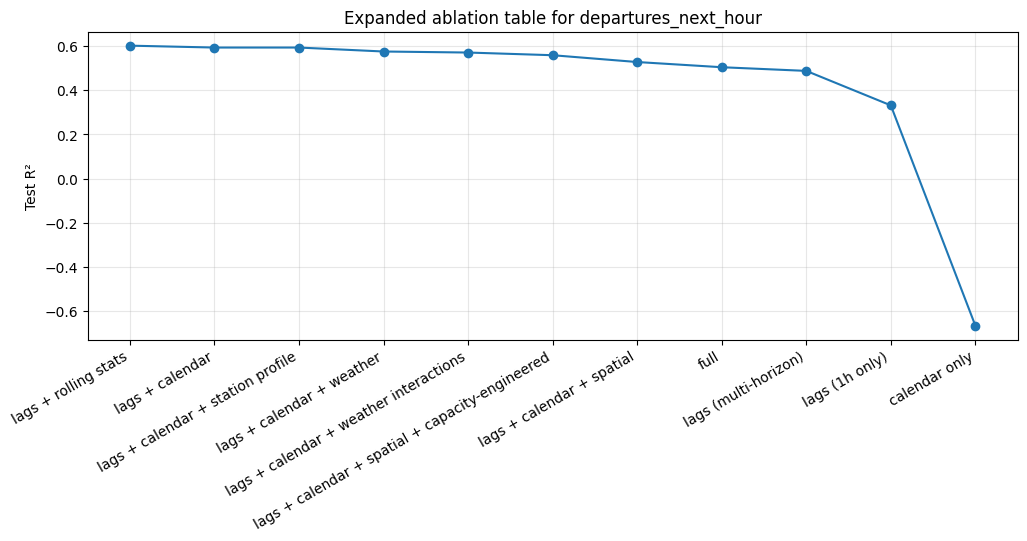

In [10]:
def run_xgb_ablation(df, target_col=TARGET_COL, top_n=TOP_N_STATIONS):
    busy = busiest_station_keys(df, target_col=target_col, top_n=top_n)
    base_cols = ["station_key", "hour", target_col]
    if "station_cluster" in df.columns:
        base_cols.append("station_cluster")

    results = []
    trained_runs = {}

    for label, raw_features in ABLATION_DEFS:
        features = [c for c in dict.fromkeys(raw_features) if c in df.columns]
        if not features:
            continue

        selected_cols = list(dict.fromkeys(base_cols + features))
        model_df = df.loc[df["station_key"].isin(busy) & df[target_col].notna(), selected_cols].copy()
        model_df = model_df.sort_values(["hour", "station_key"]).reset_index(drop=True)

        # Keep categorical columns as strings; XGBoost categorical handling will convert them later.
        for cat_col in [c for c in ["station_key", "station_cluster", "temp_bin", "capacity_bucket"] if c in model_df.columns]:
            model_df[cat_col] = model_df[cat_col].astype("string")

        train_df, valid_df, test_df = chronological_split(model_df)
        train_df, valid_df, test_df, profile_cols = apply_train_only_station_profiles(train_df, valid_df, test_df)

        final_features = [c for c in features if c in train_df.columns]
        if "station_profile" in label.lower() or label == "full":
            final_features = [c for c in dict.fromkeys(final_features + [c for c in profile_cols if c in train_df.columns])]

        model, valid_pred, test_pred = fit_xgb_regressor(train_df, valid_df, test_df, target_col, final_features)
        valid_metrics = regression_metrics(valid_df[target_col], valid_pred)
        test_metrics = regression_metrics(test_df[target_col], test_pred)

        results.append({
            "experiment": label,
            "n_features": len(final_features),
            "backend": "XGBoost CUDA" if GPU_INFO["cuda_ready_for_xgb"] else "XGBoost CPU",
            "valid_rmse": valid_metrics["rmse"],
            "valid_mae": valid_metrics["mae"],
            "valid_r2": valid_metrics["r2"],
            "test_rmse": test_metrics["rmse"],
            "test_mae": test_metrics["mae"],
            "test_r2": test_metrics["r2"],
        })
        trained_runs[label] = {
            "model": model,
            "features": final_features,
            "train_df": train_df,
            "valid_df": valid_df,
            "test_df": test_df,
            "test_pred": test_pred,
        }

    return pd.DataFrame(results).sort_values("test_r2", ascending=False).reset_index(drop=True), trained_runs


ablation_results, trained_runs = run_xgb_ablation(feature_df_exp, target_col=TARGET_COL, top_n=TOP_N_STATIONS)
display(ablation_results)

plt.figure(figsize=(12, 4))
plt.plot(ablation_results["experiment"], ablation_results["test_r2"], marker="o")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test R²")
plt.title(f"Expanded ablation table for {TARGET_COL}")
plt.grid(True, alpha=0.3)
plt.show()


## 6) Compare model families on the strongest feature set

Use this after the ablation table. It tells you whether gains are coming mostly from better features or from switching model families.


In [11]:
if len(ablation_results) == 0:
    raise RuntimeError("Ablation table is empty. Check feature columns and input data.")

best_experiment = ablation_results.iloc[0]["experiment"]
best_run = trained_runs[best_experiment]
full_features = best_run["features"]
train_df = best_run["train_df"].copy()
valid_df = best_run["valid_df"].copy()
test_df = best_run["test_df"].copy()

_, xgb_valid_pred, xgb_test_pred = fit_xgb_regressor(train_df, valid_df, test_df, TARGET_COL, full_features)
_, rf_valid_pred, rf_test_pred = fit_rf_regressor(train_df, valid_df, test_df, TARGET_COL, full_features)

model_compare = pd.DataFrame([
    {
        "model": "XGBoost",
        "backend": "GPU" if GPU_INFO["cuda_ready_for_xgb"] else "CPU",
        "valid_rmse": regression_metrics(valid_df[TARGET_COL], xgb_valid_pred)["rmse"],
        "valid_r2": regression_metrics(valid_df[TARGET_COL], xgb_valid_pred)["r2"],
        "test_rmse": regression_metrics(test_df[TARGET_COL], xgb_test_pred)["rmse"],
        "test_r2": regression_metrics(test_df[TARGET_COL], xgb_test_pred)["r2"],
    },
    {
        "model": "Random Forest",
        "backend": "CPU",
        "valid_rmse": regression_metrics(valid_df[TARGET_COL], rf_valid_pred)["rmse"],
        "valid_r2": regression_metrics(valid_df[TARGET_COL], rf_valid_pred)["r2"],
        "test_rmse": regression_metrics(test_df[TARGET_COL], rf_test_pred)["rmse"],
        "test_r2": regression_metrics(test_df[TARGET_COL], rf_test_pred)["r2"],
    },
]).sort_values("test_r2", ascending=False).reset_index(drop=True)

display(model_compare)


,model,backend,valid_rmse,valid_r2,test_rmse,test_r2
0,XGBoost,GPU,7.603097,0.688790,5.269665,0.601079
1,Random Forest,CPU,7.709823,0.679992,5.361815,0.587005


## 7) Error slicing on the current best run

This helps you see whether the new features improved the exact trouble spots from the earlier notebook: commute peaks, rain, and very high-demand periods.


### MAE by `hour_of_day`

,hour_of_day,abs_error
7,7,5.538873
16,16,5.357686
17,17,5.151100
18,18,4.664412
15,15,4.590795
6,6,4.387451
8,8,4.383273
14,14,4.341116
13,13,4.078050
9,9,3.900442


### MAE by `demand_bucket`

,demand_bucket,abs_error
4,very high,6.510108
3,high,3.489965
2,mid,3.049079
0,very low,2.786286
1,low,2.683089


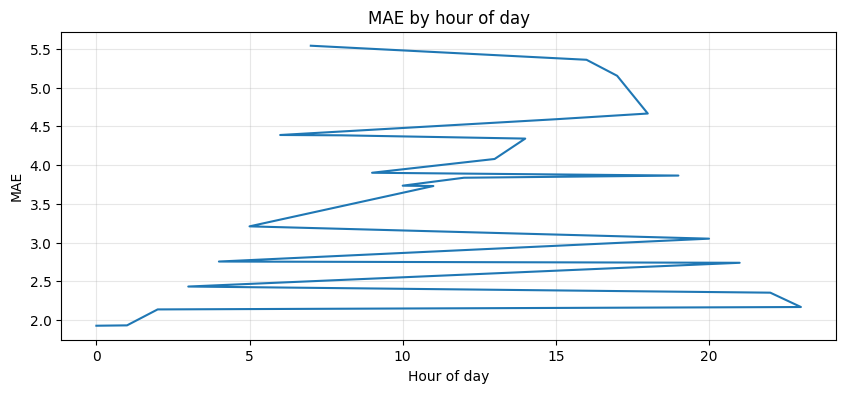

In [12]:
best_experiment = ablation_results.iloc[0]["experiment"]
best_run = trained_runs[best_experiment]
error_df = best_run["test_df"].copy()
error_df["prediction"] = best_run["test_pred"]
error_df["abs_error"] = (error_df[TARGET_COL] - error_df["prediction"]).abs()
error_df["hour_of_day"] = pd.to_datetime(error_df["hour"]).dt.hour
error_df["demand_bucket"] = pd.qcut(error_df[TARGET_COL].rank(method="first"), q=5, labels=["very low", "low", "mid", "high", "very high"])

slice_tables = {}
for col in ["hour_of_day", "is_precipitating", "is_weekend", "is_commute_peak", "station_cluster", "demand_bucket"]:
    if col in error_df.columns:
        slice_tables[col] = error_df.groupby(col, as_index=False)["abs_error"].mean().sort_values("abs_error", ascending=False)

for name, table in slice_tables.items():
    display(Markdown(f"### MAE by `{name}`"))
    display(table.head(20))

if "hour_of_day" in slice_tables:
    plt.figure(figsize=(10, 4))
    plt.plot(slice_tables["hour_of_day"]["hour_of_day"], slice_tables["hour_of_day"]["abs_error"])
    plt.title("MAE by hour of day")
    plt.xlabel("Hour of day")
    plt.ylabel("MAE")
    plt.grid(True, alpha=0.3)
    plt.show()


## 8) Optional extension: segmented models by station demand tier

This tests whether one global model is averaging away patterns across low-volume and high-volume stations.


In [13]:
def run_segmented_models(df, feature_cols, target_col=TARGET_COL, top_n=TOP_N_STATIONS):
    busy = busiest_station_keys(df, target_col=target_col, top_n=top_n)
    model_df = df.loc[df["station_key"].isin(busy) & df[target_col].notna(), ["station_key", "hour", target_col] + feature_cols].copy()
    model_df = model_df.sort_values(["hour", "station_key"]).reset_index(drop=True)
    train_df, valid_df, test_df = chronological_split(model_df)

    station_activity = train_df.groupby("station_key", observed=True)[target_col].mean()
    try:
        tiers = pd.qcut(station_activity.rank(method="first"), q=3, labels=["low", "mid", "high"])
    except Exception:
        tiers = pd.cut(station_activity.rank(method="first"), bins=3, labels=["low", "mid", "high"])
    tier_map = tiers.astype("string")

    rows = []
    for tier in ["low", "mid", "high"]:
        keys = tier_map[tier_map == tier].index.astype("string")
        tr = train_df[train_df["station_key"].astype("string").isin(keys)].copy()
        va = valid_df[valid_df["station_key"].astype("string").isin(keys)].copy()
        te = test_df[test_df["station_key"].astype("string").isin(keys)].copy()
        if min(len(tr), len(va), len(te)) == 0:
            continue
        tr, va, te, profile_cols = apply_train_only_station_profiles(tr, va, te)
        final_features = [c for c in dict.fromkeys(feature_cols + [c for c in profile_cols if c in tr.columns])]
        _, _, test_pred = fit_xgb_regressor(tr, va, te, target_col, final_features)
        metrics = regression_metrics(te[target_col], test_pred)
        rows.append({"tier": tier, "n_train": len(tr), "n_test": len(te), "test_rmse": metrics["rmse"], "test_r2": metrics["r2"]})
    return pd.DataFrame(rows)

segmented_results = run_segmented_models(feature_df_exp, full_features, target_col=TARGET_COL, top_n=TOP_N_STATIONS)
display(segmented_results)


,tier,n_train,n_test,test_rmse,test_r2
0,low,187690,39272,4.298352,0.524818
1,mid,182714,37613,5.087119,0.574466
2,high,191840,39447,6.230168,0.622741


## 9) Optional extension: high-demand alert classification

This gives you a practical operational task if exact regression gains are modest.


In [15]:
def fit_xgb_classifier(train_df, valid_df, test_df, target_col, feature_cols):
    X_train, X_valid, X_test = clean_xgb_frames(train_df, valid_df, test_df, feature_cols)
    y_train = train_df[target_col].astype(int)
    y_valid = valid_df[target_col].astype(int)
    y_test = test_df[target_col].astype(int)

    params = dict(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=400,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=4,
        subsample=0.85,
        colsample_bytree=0.85,
        tree_method="hist",
        random_state=RANDOM_STATE,
        early_stopping_rounds=40,
        enable_categorical=True,
    )
    if GPU_INFO["cuda_ready_for_xgb"]:
        params["device"] = "cuda"

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    valid_prob = model.predict_proba(X_valid)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    valid_pred = (valid_prob >= 0.5).astype(int)
    test_pred = (test_prob >= 0.5).astype(int)

    metrics = pd.DataFrame([
        {
            "split": "validation",
            "precision": precision_score(y_valid, valid_pred, zero_division=0),
            "recall": recall_score(y_valid, valid_pred, zero_division=0),
            "f1": f1_score(y_valid, valid_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, valid_prob),
        },
        {
            "split": "test",
            "precision": precision_score(y_test, test_pred, zero_division=0),
            "recall": recall_score(y_test, test_pred, zero_division=0),
            "f1": f1_score(y_test, test_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, test_prob),
        },
    ])
    return model, metrics


def run_high_demand_alert_task(df, target_col=TARGET_COL, top_n=TOP_N_STATIONS, quantile=0.90):
    busy = busiest_station_keys(df, target_col=target_col, top_n=top_n)
    candidate_features = [c for c in dict.fromkeys(FEATURE_GROUPS["lags_multi"] + FEATURE_GROUPS["rolling_stats"] + FEATURE_GROUPS["calendar_only"] + FEATURE_GROUPS["weather_raw"] + FEATURE_GROUPS["weather_interactions"] + FEATURE_GROUPS["spatial"] + FEATURE_GROUPS["capacity_engineered"] + FEATURE_GROUPS["station_profile"]) if c in df.columns]

    selected_cols = list(dict.fromkeys(["station_key", "hour", target_col] + candidate_features))
    model_df = df.loc[df["station_key"].isin(busy) & df[target_col].notna(), selected_cols].copy()
    model_df = model_df.sort_values(["hour", "station_key"]).reset_index(drop=True)
    train_df, valid_df, test_df = chronological_split(model_df)

    thresholds = train_df.groupby("station_key", observed=True)[target_col].quantile(quantile)
    for frame in [train_df, valid_df, test_df]:
        frame["station_threshold"] = frame["station_key"].map(thresholds)
        frame["high_demand_next_hour"] = (frame[target_col] >= frame["station_threshold"]).astype(int)

    train_df, valid_df, test_df, profile_cols = apply_train_only_station_profiles(train_df, valid_df, test_df)
    feature_cols = [c for c in dict.fromkeys(candidate_features + [c for c in profile_cols if c in train_df.columns]) if c in train_df.columns]
    _, clf_metrics = fit_xgb_classifier(train_df, valid_df, test_df, "high_demand_next_hour", feature_cols)
    return clf_metrics

alert_metrics = run_high_demand_alert_task(feature_df_exp, target_col=TARGET_COL, top_n=TOP_N_STATIONS, quantile=0.90)
display(alert_metrics)


,split,precision,recall,f1,roc_auc
0,validation,0.750604,0.695786,0.722156,0.944528
1,test,0.394223,0.666810,0.495502,0.952574


## 10) Save the main outputs

These files are handy for your report writeup and for comparing reruns after feature changes.


In [16]:
output_dir = Path("/content/outputs_follow_on")
output_dir.mkdir(parents=True, exist_ok=True)

ablation_results.to_csv(output_dir / "expanded_ablation_results.csv", index=False)
model_compare.to_csv(output_dir / "model_family_comparison.csv", index=False)
if 'segmented_results' in globals():
    segmented_results.to_csv(output_dir / "segmented_results.csv", index=False)
if 'alert_metrics' in globals():
    alert_metrics.to_csv(output_dir / "alert_metrics.csv", index=False)

print("Saved outputs to:", output_dir)
print(sorted(p.name for p in output_dir.iterdir()))


Saved outputs to: /content/outputs_follow_on
['alert_metrics.csv', 'expanded_ablation_results.csv', 'model_family_comparison.csv', 'segmented_results.csv']


## 11) How to read the results

A good outcome pattern would look like this:

- **multi-horizon lags + rolling stats** beat 1-hour-only lags
- **station profile** beats plain lags + calendar
- **spatial spillovers** beat plain weather
- **capacity-engineered** helps more than raw capacity alone
- **XGBoost** beats Random Forest on the strongest feature set

If the gains are still small, the classification cell can still give you a stronger practical result than forcing exact net-flow regression.
